In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import NoiseModel, depolarizing_error,ReadoutError

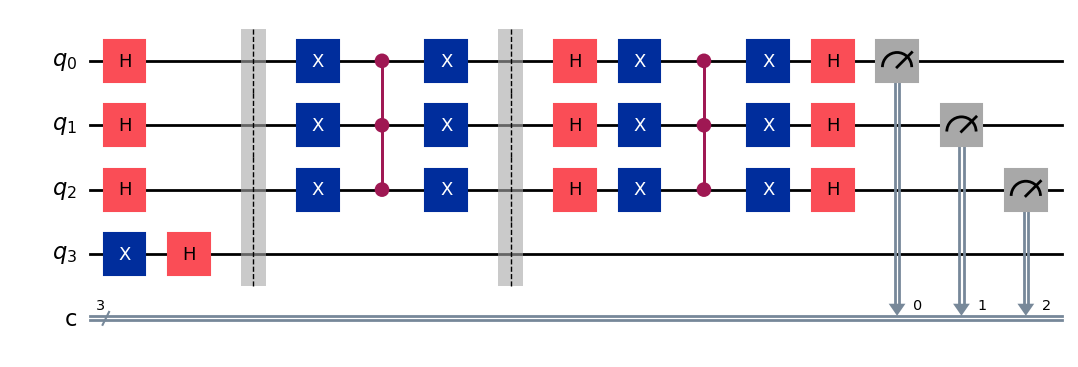

In [7]:
# winning state = |0>
# 3 qubit sysytem
grover = QuantumCircuit(4,3)
grover.x(3)
grover.h(range(4))
grover.barrier()

# oracle with winning state |000>
grover.x(range(3))
grover.ccz(0,1,2) 
grover.x(range(3)) 
grover.barrier()

# diffuser 
grover.h(range(3))
grover.x(range(3))
grover.ccz(0,1,2)
grover.x(range(3))
grover.h(range(3))

grover.measure([0,1,2],[0,1,2])
grover.draw('mpl')

In [8]:
aer = AerSimulator()
counts = aer.run(grover,shots=1000).result().get_counts()
counts

{'000': 779,
 '101': 22,
 '100': 32,
 '111': 31,
 '001': 37,
 '011': 36,
 '110': 39,
 '010': 24}

General Grover Algorithm for n qubits


<>:10: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:18: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:10: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:18: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
C:\Users\Admin\AppData\Local\Temp\ipykernel_19676\546997000.py:10: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if j is '0':
C:\Users\Admin\AppData\Local\Temp\ipykernel_19676\546997000.py:18: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if j is '0':


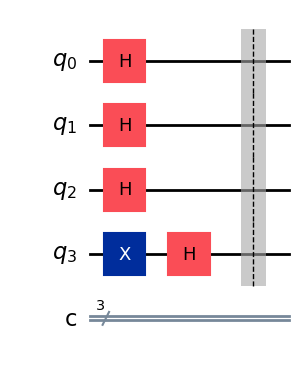

Circuit After Oracle


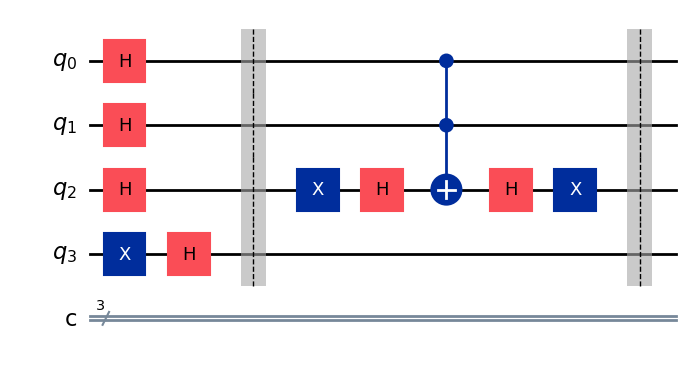

grover circuit after diffuser 



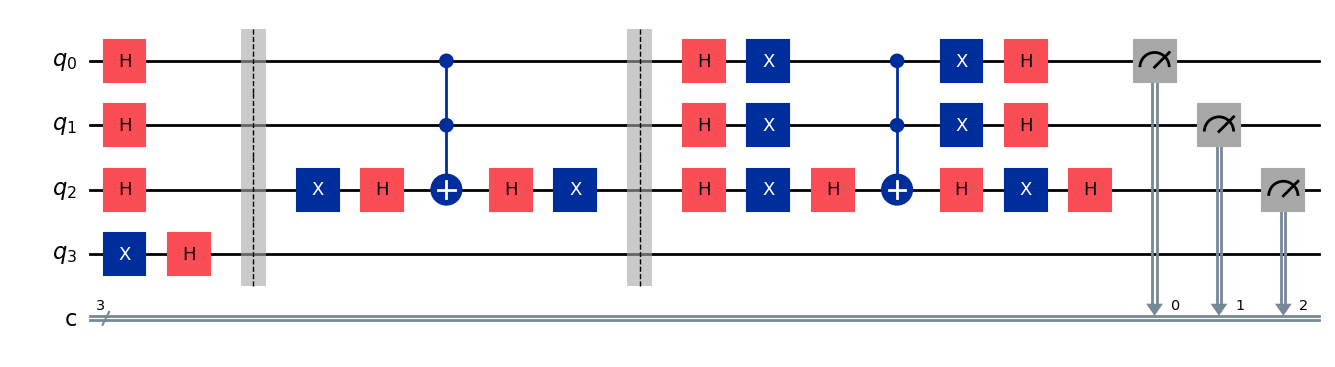

In [21]:
def initialization(grover_circuit,n):
    grover_circuit.x(n)
    grover_circuit.h(range(n+1))
    grover_circuit.barrier()
    display(grover_circuit.draw('mpl')) 


def oracle(grover_circuit,winning_state,n):
    for i,j in enumerate(winning_state):
        if j is '0':
            grover_circuit.x(i) 
    
    grover_circuit.h(n-1)
    grover_circuit.mcx(list(range(n-1)),n-1)
    grover_circuit.h(n-1)

    for i,j in enumerate(winning_state):
        if j is '0':
            grover_circuit.x(i)
    
    print("Circuit After Oracle")
    grover_circuit.barrier()
    display(grover_circuit.draw('mpl'))
    
def diffuser(grover_circuit,n):
    grover_circuit.h(range(n))
    grover_circuit.x(range(n))
    grover_circuit.h(n-1)
    grover_circuit.mcx(list(range(n-1)),n-1)
    grover_circuit.h(n-1)
    grover_circuit.x(range(n))
    grover_circuit.h(range(n))
    grover_circuit.measure(list(range(n)),list(range(n)))
    print("grover circuit after diffuser \n")
    display(grover_circuit.draw('mpl'))
n=3
grover_circuit = QuantumCircuit(n+1,n) 
initialization(grover_circuit,n)
winning_state = '110' 
oracle(grover_circuit,winning_state,n) 
diffuser(grover_circuit,n)



In [22]:
aer = AerSimulator()
counts = aer.run(grover_circuit,shots=1000).result().get_counts()
counts

{'011': 779,
 '001': 33,
 '111': 32,
 '000': 28,
 '100': 47,
 '110': 31,
 '010': 30,
 '101': 20}